In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


LOADING DATASET

In [2]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


EXPLORING

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 7043
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

CHECKING MISSING VALUES

In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Clean TotalCharges

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

Remove Missing Records

In [6]:
df = df.dropna()

df.shape

(7032, 21)

Churn Distribution

In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


Plot

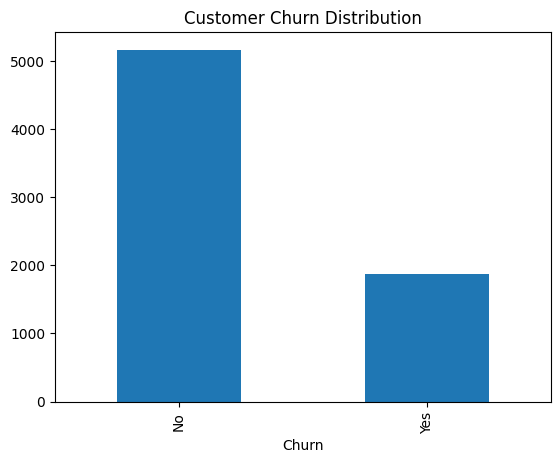

In [8]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.show()

SQL Analysis

In [9]:
import sqlite3

conn = sqlite3.connect('telecom.db')

df.to_sql('customers',
          conn,
          if_exists='replace',
          index=False)

7032

Query 1: Churn by Contract Type

In [10]:
query = """
SELECT Contract,
COUNT(*) AS Total_Customers
FROM customers
GROUP BY Contract
"""

pd.read_sql(query, conn)

,Contract,Total_Customers
0,Month-to-month,3875
1,One year,1472
2,Two year,1685


Query 2: Average Monthly Charges

In [11]:
query = """
SELECT
AVG(MonthlyCharges) AS Avg_Monthly_Charge
FROM customers
"""

pd.read_sql(query, conn)

,Avg_Monthly_Charge
0,64.798208


Query 3: Churn Count

In [12]:
query = """
SELECT
Churn,
COUNT(*) AS Customers
FROM customers
GROUP BY Churn
"""

pd.read_sql(query, conn)

,Churn,Customers
0,No,5163
1,Yes,1869


Encode target:

In [13]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [14]:
df_encoded = pd.get_dummies(df,
                            drop_first=True)

Split Data

In [15]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn',
                    axis=1)

y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

Evaluate

In [17]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)

accuracy_score(y_test,
               predictions)

0.7924662402274343

Exporting Clean Data

In [18]:
df.to_csv(
    'cleaned_telco_data.csv',
    index=False
)

DOWNLOADING CLEAN DATA

In [19]:
files.download(
    'cleaned_telco_data.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>